# 02 — Styling
**Goal:** Make charts look professional. Default matplotlib is ugly — styling is what separates a quick EDA chart from something you'd put in a presentation.

Topics:
- Colors
- Line styles and markers
- Fonts and text size
- Spines and grid
- Built-in themes (`style`)
- `rcParams` — setting global defaults once

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
days = np.arange(1, 31)
organic  = np.random.randint(200, 800, 30).cumsum() / 100
paid     = np.random.randint(100, 600, 30).cumsum() / 100
email    = np.random.randint(50,  300, 30).cumsum() / 100

## 1. Colors
You can use named colors, hex codes, or RGB tuples.

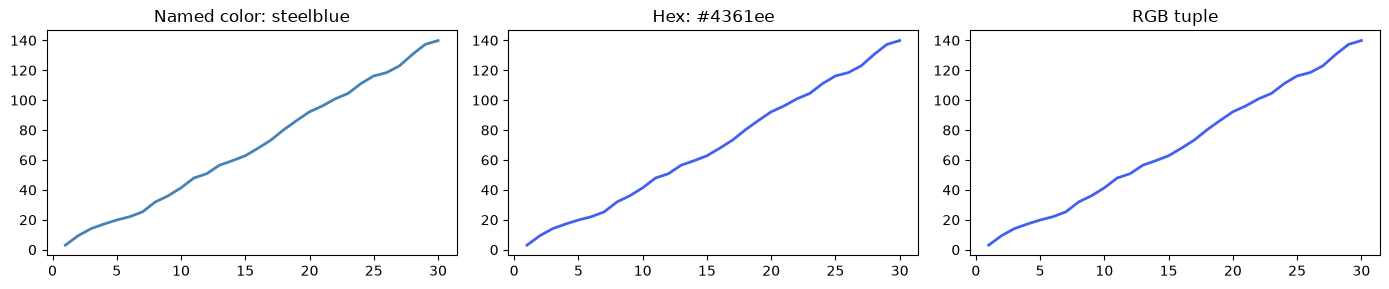

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

# Named colors (easy to read in code)
axes[0].plot(days, organic, color='steelblue', linewidth=2)
axes[0].set_title('Named color: steelblue')

# Hex codes (precise, matches brand colors)
axes[1].plot(days, organic, color='#4361ee', linewidth=2)
axes[1].set_title('Hex: #4361ee')

# RGB tuple — values between 0 and 1
axes[2].plot(days, organic, color=(0.26, 0.38, 0.93), linewidth=2)
axes[2].set_title('RGB tuple')

plt.tight_layout()
plt.show()

## 2. Line styles and markers

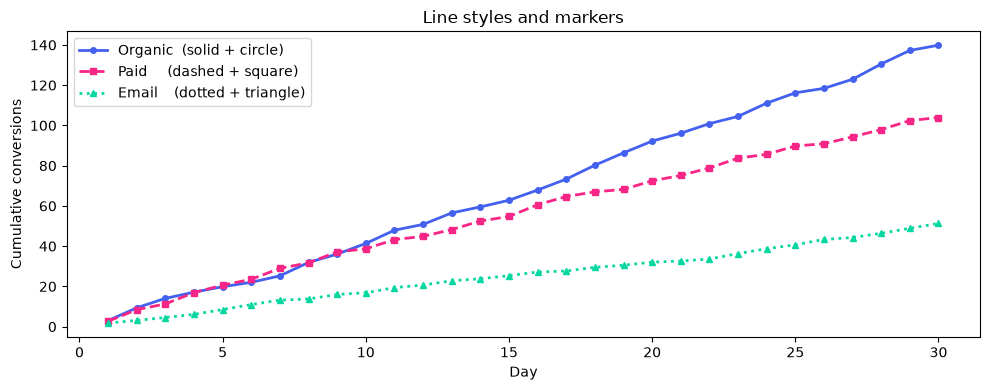

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

# linestyle controls the line pattern
# linewidth controls thickness
# marker adds a shape at each data point
# markersize controls marker size
ax.plot(days, organic, color='#4361ee', linewidth=2,
        linestyle='-',    marker='o', markersize=4,  label='Organic  (solid + circle)')

ax.plot(days, paid,    color='#f72585', linewidth=2,
        linestyle='--',   marker='s', markersize=4,  label='Paid     (dashed + square)')

ax.plot(days, email,   color='#06d6a0', linewidth=2,
        linestyle=':',    marker='^', markersize=5,  label='Email    (dotted + triangle)')

ax.set_title('Line styles and markers')
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative conversions')
ax.legend()

plt.tight_layout()
plt.show()

# Available linestyles: '-'  '--'  '-.'  ':'
# Available markers:   'o'  's'  '^'  'v'  'D'  'x'  '+'  '*'

## 3. Fonts and text size

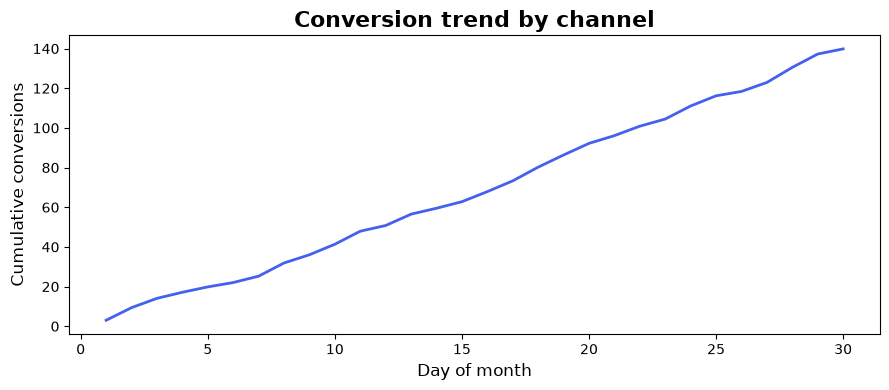

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(days, organic, color='#4361ee', linewidth=2)

# fontsize can be a number or a named size: 'small', 'medium', 'large', 'x-large'
ax.set_title('Conversion trend by channel', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of month', fontsize=12)
ax.set_ylabel('Cumulative conversions', fontsize=12)

# Tick label size (the numbers on the axes)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

## 4. Spines and grid
**Spines** are the four borders of the chart.  
Removing top and right spines is the single most impactful styling change.

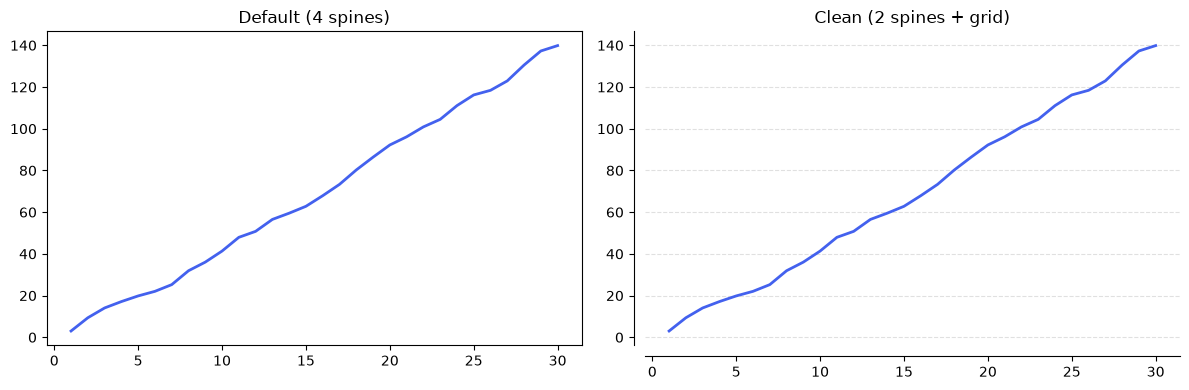

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Default — all 4 spines visible
ax1.plot(days, organic, color='#4361ee', linewidth=2)
ax1.set_title('Default (4 spines)')

# Clean — remove top and right spines
ax2.plot(days, organic, color='#4361ee', linewidth=2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Subtle horizontal grid — helps reading values without visual noise
ax2.grid(axis='y', color='#e0e0e0', linewidth=0.8, linestyle='--')

# Push the left and bottom spines slightly inward
ax2.spines['left'].set_position(('outward', 8))
ax2.spines['bottom'].set_position(('outward', 8))

ax2.set_title('Clean (2 spines + grid)')

plt.tight_layout()
plt.show()

## 5. Built-in themes with `plt.style`
Matplotlib ships with ready-made themes you can apply instantly.

In [6]:
# See all available styles
print(plt.style.available)

['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


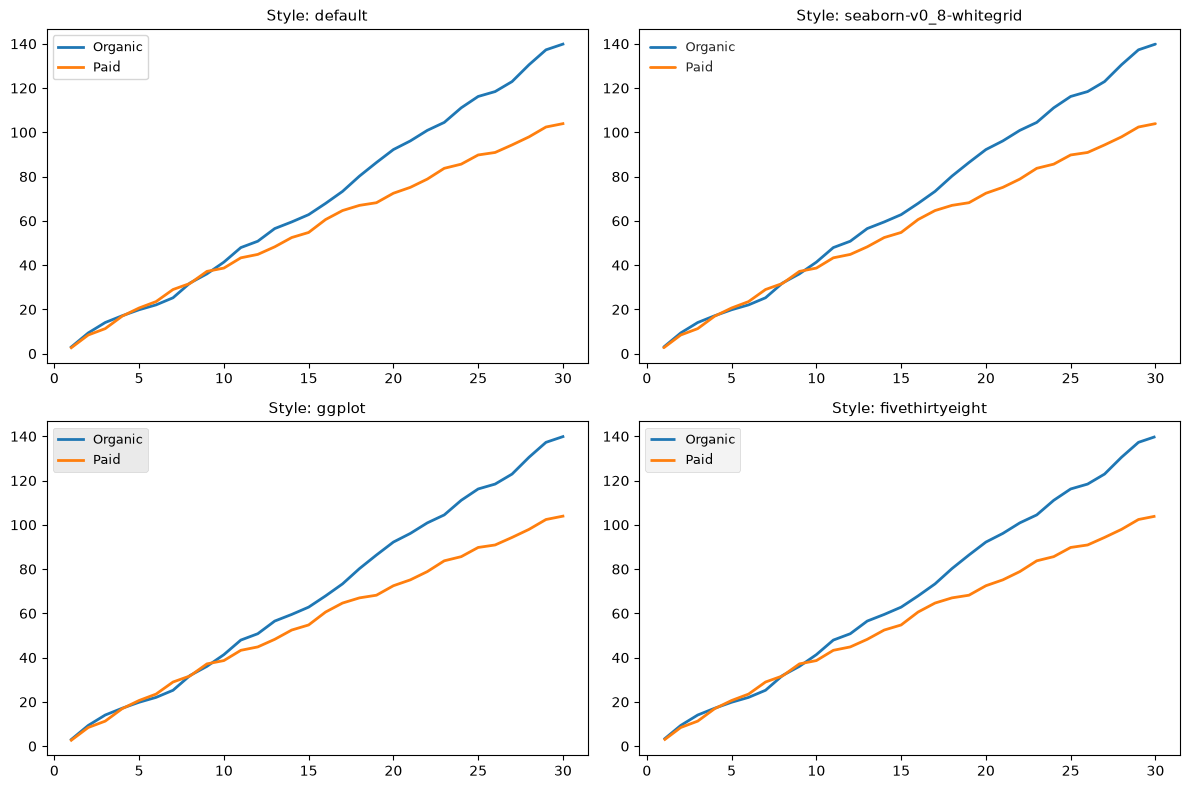

In [7]:
styles_to_compare = ['default', 'seaborn-v0_8-whitegrid', 'ggplot', 'fivethirtyeight']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # flatten converts 2D array of axes to 1D for easy iteration

for ax, style in zip(axes, styles_to_compare):
    with plt.style.context(style):   # context() applies style only inside the block
        ax.plot(days, organic, linewidth=2, label='Organic')
        ax.plot(days, paid,    linewidth=2, label='Paid')
        ax.set_title(f'Style: {style}', fontsize=11)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. `rcParams` — set global defaults once
Instead of repeating `fontsize=12` on every chart, set it once at the top of your notebook.

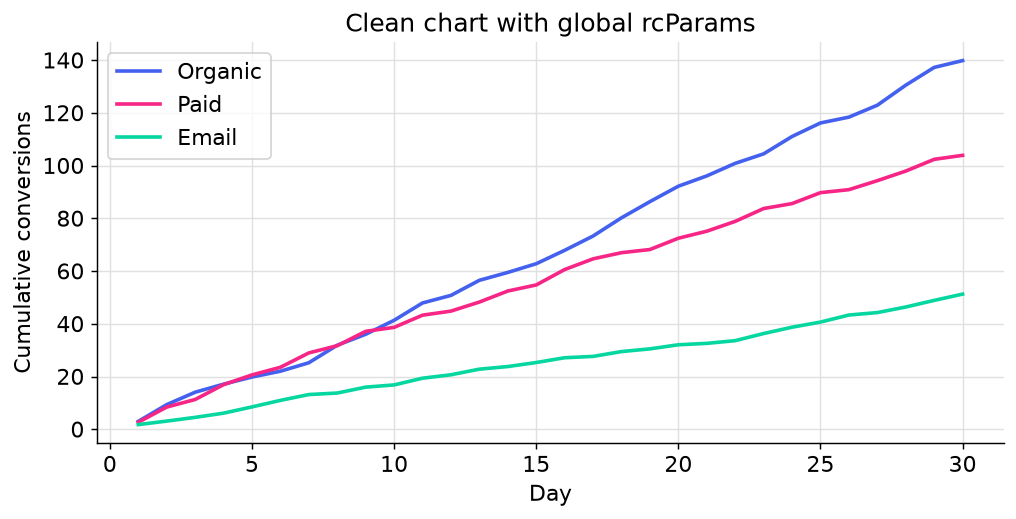

In [ ]:
# Set once at the top of your notebook or script
# All charts after this will use these defaults
plt.rcParams.update({
    'figure.figsize':    (9, 4),       # default figure size
    'figure.dpi':        130,           # default resolution
    'axes.spines.top':   False,         # remove top spine globally
    'axes.spines.right': False,         # remove right spine globally
    'axes.grid':         True,          # show grid by default
    'grid.color':        '#e0e0e0',     # grid color
    'grid.linewidth':    0.8,
    'font.size':         12,            # base font size
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'lines.linewidth':   2,
})

# Now every chart inherits these settings automatically
fig, ax = plt.subplots()
ax.plot(days, organic, color='#4361ee', label='Organic')
ax.plot(days, paid,    color='#f72585', label='Paid')
ax.plot(days, email,   color='#06d6a0', label='Email')
ax.set_title('Clean chart with global rcParams')
ax.set_xlabel('Day')
ax.set_ylabel('Cumulative conversions')
ax.legend()
plt.show()

## 7. Putting it all together — a presentation-ready chart

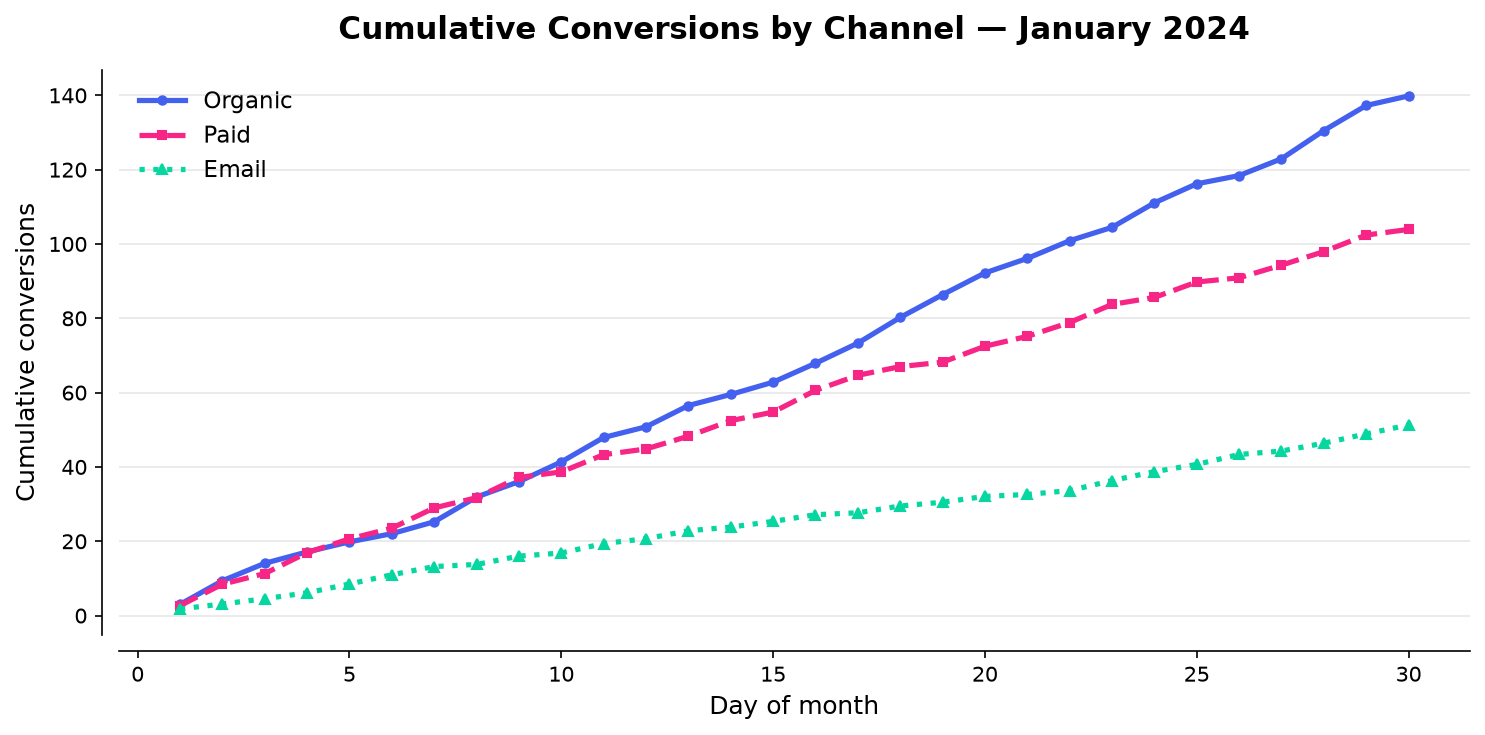

In [9]:
# Reset to defaults first so this cell is self-contained
plt.rcdefaults()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# Data
ax.plot(days, organic, color='#4361ee', linewidth=2.5, marker='o',
        markersize=4, label='Organic')
ax.plot(days, paid,    color='#f72585', linewidth=2.5, linestyle='--',
        marker='s', markersize=4, label='Paid')
ax.plot(days, email,   color='#06d6a0', linewidth=2.5, linestyle=':',
        marker='^', markersize=5, label='Email')

# Labels
ax.set_title('Cumulative Conversions by Channel — January 2024',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Day of month', fontsize=12)
ax.set_ylabel('Cumulative conversions', fontsize=12)

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 8))
ax.spines['bottom'].set_position(('outward', 8))

# Subtle grid
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)   # grid lines go behind the data

# Legend outside the plot to avoid covering data
ax.legend(fontsize=11, frameon=False, loc='upper left')

# Tick label size
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('data/02_styling_final.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
| What | How |
|---|---|
| Color | `color='#hex'` or `color='name'` |
| Line style | `linestyle='-'` `'--'` `':'` `'-.'` |
| Marker | `marker='o'` `'s'` `'^'` etc |
| Font size | `fontsize=12` on any text method |
| Remove spines | `ax.spines['top'].set_visible(False)` |
| Grid | `ax.grid(axis='y', color='#e0e0e0')` |
| Grid behind data | `ax.set_axisbelow(True)` |
| Global defaults | `plt.rcParams.update({...})` |
| Built-in themes | `plt.style.use('ggplot')` |

**Next:** `03_chart_types.ipynb` — bar, histogram, boxplot, scatter and when to use each.